# Exploring NMF and PCA on Handwritten Digit Images

## Notebook Summary

This notebook used the classic handwritten digits dataset from scikit-learn to explore how two unsupervised models—Non-negative Matrix Factorization (NMF) and Principal Component Analysis (PCA)—"see" and represent images.

## What We Did

- **Loaded the digits dataset**
  - Observed the data in two forms:
    - `samples` with shape `(1797, 64)`: each digit flattened into a 64-dimensional vector (8×8 pixels).
    - `images` with shape `(1797, 8, 8)`: each digit as a 2D image, suitable for plotting.

- **Fitted an NMF model**
  - Used `NMF(n_components=7, random_state=0)` and `fit_transform(samples)`.
  - Visualized `model.components_` with `show_as_image(component)`.
  - Observed that each component looked like a **part** of digits (e.g., a bar or stroke), often mostly black with a small bright region.
  - Looked at `features[0]` (the first row of the NMF features matrix) and interpreted it as the **recipe of parts** used to reconstruct that specific digit.

- **Fitted a PCA model**
  - Used `PCA(n_components=7)` and `fit_transform(samples)`.
  - Visualized `model.components_` and saw that PCA components looked like **whole-digit templates** with both positive and negative regions, not clean parts.
  - Noted that PCA does **not** learn parts; it learns directions of maximum variance.

- **Compared original digits and model-based views**
  - Distinguished between:
    - **Raw digits** from the dataset (e.g., `samples[0]` or `images[0]`).
    - **Learned components** from NMF or PCA (`model.components_`), which are not original digits but patterns the models invented to explain the dataset.
  - Discussed how PCA reconstructions of a digit (using a limited number of components) can look **cleaner and more idealized** than the original, because PCA acts like a low-rank, denoising approximation.

## Key Ideas Learned

- **Shape of the data matters**
  - `(1797, 64)` means 1797 samples, each represented by 64 features (pixels).
  - `(1797, 8, 8)` is the same data in image form.

- **NMF as "parts-based" representation**
  - Components are non-negative and tend to be sparse.
  - Each component resembles a **part** of a digit (segments, bars, strokes).
  - A digit is expressed as a non-negative combination of these parts (like mixing only additive paint).

- **PCA as "directions of variance"**
  - Components can have positive and negative values.
  - Each component is more like a **global template** over the whole image.
  - PCA is not aware of digit labels (0–9); it just captures how pixel intensities vary together.

- **Reconstruction and perception**
  - Reconstructing a digit from a small number of PCA components can:
    - Remove noise.
    - Emphasize big shapes and tones.
    - Sometimes make the digit look more like an ideal example to human eyes.

## Personal Analogy and Artistic Insight

- From the perspective of classical fine art training:
  - **Original digit** = raw observational drawing with all the specific quirks and noise.
  - **PCA with many components** = a cleaned-up academic rendering that still keeps most detail.
  - **PCA with very few components** = a strong, simplified value sketch—entering the territory of early modernism, where only the main masses and rhythms survive.
- NMF feels like building images from a **library of reusable strokes or segments**, while PCA feels like **compressing the entire visual impression into a few dominant visual themes**.

## Takeaways

- Unsupervised models like NMF and PCA can reveal very different internal "vocabularies" for representing the same images.
- NMF encourages a mental model of **parts and assemblies**.
- PCA encourages a mental model of **global gestures and averaged templates**.
- Visualizing components is a powerful way to bridge mathematical models with artistic and intuitive understanding of images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
samples = digits.data        # shape: (n_samples, 64)
images = digits.images       # shape: (n_samples, 8, 8)

print(samples.shape, images.shape)


(1797, 64) (1797, 8, 8)


In [2]:
def show_as_image(component, shape=(8, 8), cmap="gray"):
    plt.imshow(component.reshape(shape), cmap=cmap)
    plt.axis("off")
    plt.show()


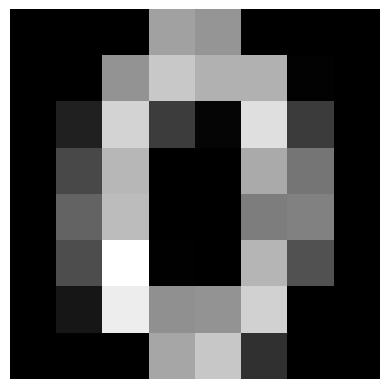

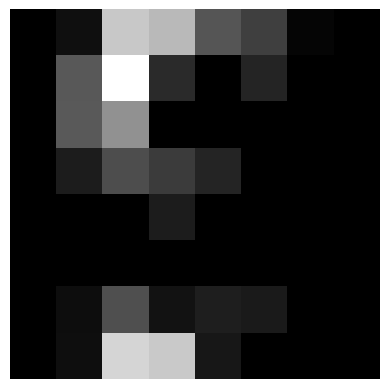

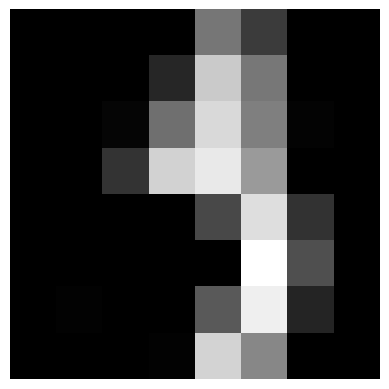

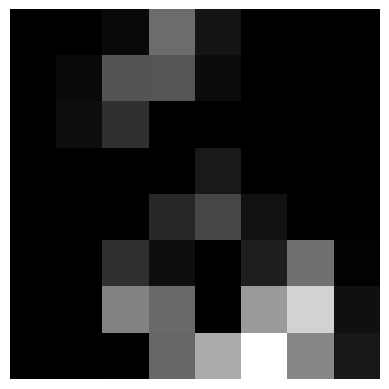

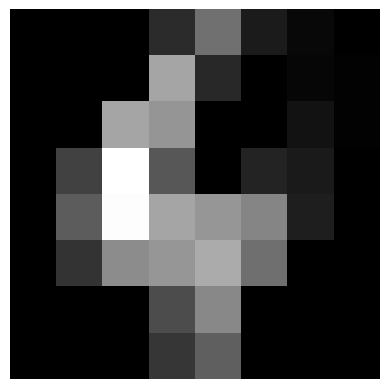

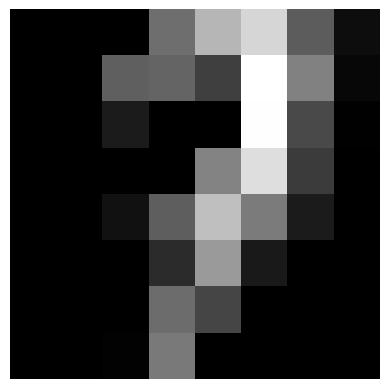

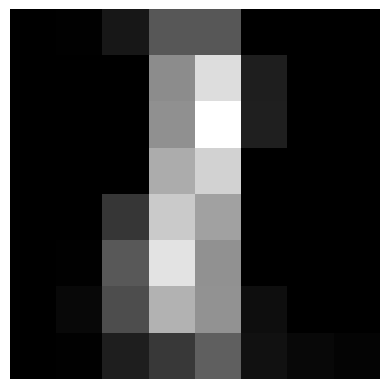

In [3]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=7, random_state=0)
features_nmf = nmf.fit_transform(samples)

for comp in nmf.components_:
    show_as_image(comp)


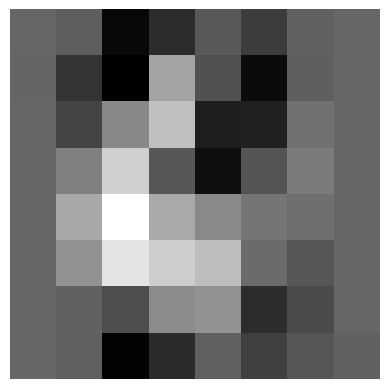

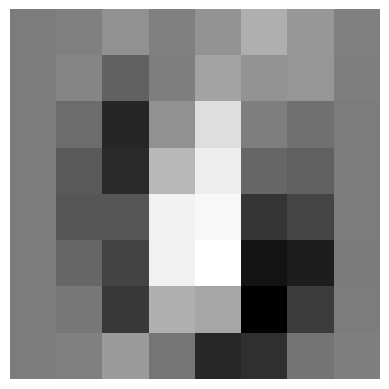

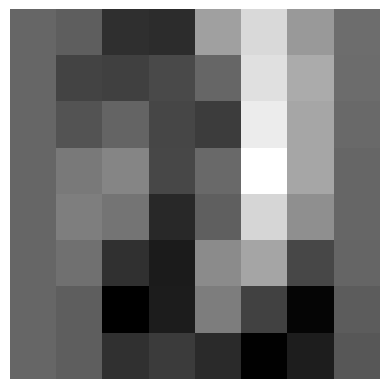

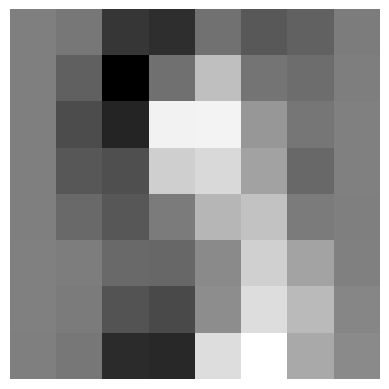

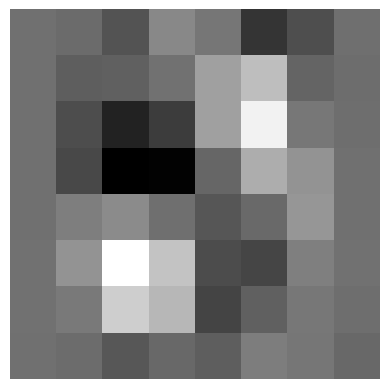

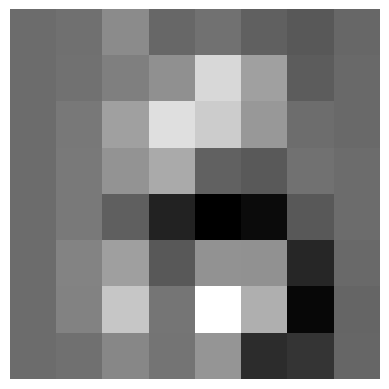

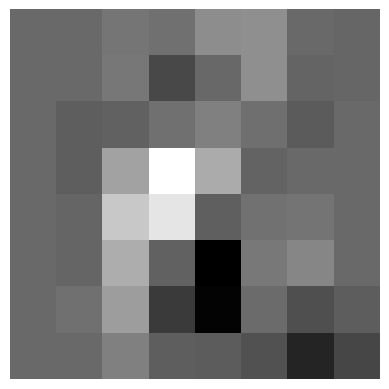

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)
features_pca = pca.fit_transform(samples)

for comp in pca.components_:
    show_as_image(comp)


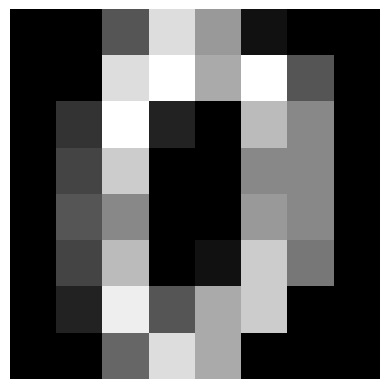

Label: 0


In [5]:
# Show an actual digit from the dataset
show_as_image(samples[0])

# (optional) see which digit it is
print("Label:", digits.target[0])


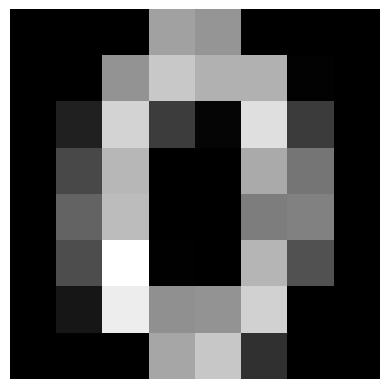

In [6]:
from sklearn.decomposition import NMF

model = NMF(n_components=7, random_state=0)
features = model.fit_transform(samples)

# Show one learned part (component 0)
show_as_image(model.components_[0])


## Summary (Version 2) – Digits as a Playground for ML

In this notebook I treated the handwritten digits dataset as a small “image school” for machine learning, exploring both **unsupervised** and **supervised** views of the same images.

### Data

- `X` / `samples`: shape `(1797, 64)` – 1797 digits as flattened 8×8 grayscale images.
- `images`: shape `(1797, 8, 8)` – the same digits in 2D, suitable for plotting.
- `y` / `digits.target`: labels 0–9.

---

### Unsupervised: NMF, PCA, K‑means

**NMF (Non‑negative Matrix Factorization)**  
- `NMF(n_components=7)` on `X`.  
- `model.components_`: learned **parts** of digits (bars, segments, strokes), mostly black with a small bright area.  
- `features[i]`: non‑negative **recipe of parts** for digit *i*.  
- Artistic view: like building digits from a limited library of reusable brushstrokes.

**PCA (Principal Component Analysis)**  
- `PCA(n_components=7)` and also `PCA(n_components=20)` on `X`.  
- `components_`: **global templates / directions of variance**, with positive and negative regions, not clean parts.  
- Reconstructing a digit from a few components produces a smoother, more “idealized” version:
  - Like simplifying a classical drawing into big value masses and losing small noise.
- Artistic view: with very few components, PCA feels like entering early modernism – bold shapes, less detail.

**K‑means clustering**  
- K‑means on **raw pixels** and on **PCA‑20 features** with `n_clusters=10`.  
- Confusion matrices (rows = true digits, cols = clusters) showed:
  - Clear clusters for visually distinctive digits (0, 4, 6, 7).  
  - Mixed clusters for similar shapes (1, 2, 5, 8, 9).  
- Cluster centers, visualized as images, look like **average shapes** of each “family”:
  - Example: the “8‑cluster” center was a vertical form with a thick middle, attracting many 8s but also some 1s, 2s, etc.
- Unsupervised lesson: K‑means discovers **shape families**, not exact digit labels.

---

### Supervised: Logistic Regression and k‑NN

Here I used the labels 0–9 and asked models to **name** digits.

**Logistic Regression**
```text
Test accuracy ≈ 0.958


In [7]:
from sklearn.datasets import load_digits
digits = load_digits()
samples = digits.data

from sklearn.decomposition import PCA
model = PCA(n_components=7)
features = model.fit_transform(samples)

def show_as_image(x, shape=(8, 8), cmap="gray"):
    import matplotlib.pyplot as plt
    plt.imshow(x.reshape(shape), cmap=cmap)
    plt.axis("off")
    plt.show()


Original 0 from dataset (index: 0 )


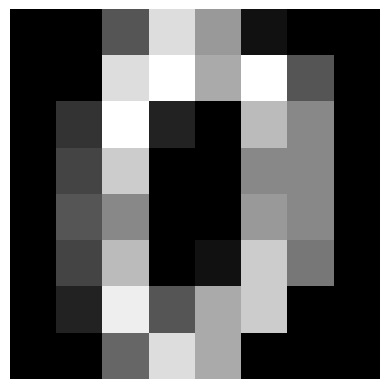

Same 0 reconstructed from PCA components:


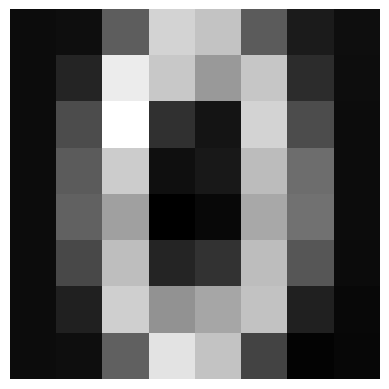

In [8]:
import numpy as np

# 1) Find one digit that is actually a 0 in the dataset
zero_index = np.where(digits.target == 0)[0][0]

# 2) Show the original 0
print("Original 0 from dataset (index:", zero_index, ")")
show_as_image(samples[zero_index])

# 3) Project this 0 into PCA space
zero_sample = samples[zero_index:zero_index+1]   # keep 2D shape (1, 64)
zero_pca = model.transform(zero_sample)

# 4) Reconstruct it back from PCA components
zero_recon = model.inverse_transform(zero_pca)

print("Same 0 reconstructed from PCA components:")
show_as_image(zero_recon[0])


In [9]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1) Load data (you may already have this)
digits = load_digits()
X = digits.data      # (1797, 64) flattened pixels
y = digits.target    # (1797,) labels 0–9

# 2) Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# 3) Train a simple classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# 4) Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print("\nClassification report:\n", classification_report(y_test, y_pred))


Test accuracy: 0.9583333333333334

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.85      0.97      0.91        36
           2       1.00      0.97      0.99        35
           3       0.97      1.00      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.95      0.96        37
           6       0.97      0.97      0.97        36
           7       0.97      0.97      0.97        36
           8       0.94      0.86      0.90        35
           9       0.95      0.97      0.96        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



In [10]:
from sklearn.decomposition import PCA

# Reduce to 20D with PCA
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca, y, test_size=0.2, random_state=0, stratify=y
)

clf_pca = LogisticRegression(max_iter=1000)
clf_pca.fit(X_train_p, y_train_p)

y_pred_p = clf_pca.predict(X_test_p)
print("Test accuracy with PCA features:", accuracy_score(y_test_p, y_pred_p))


Test accuracy with PCA features: 0.9611111111111111


In [11]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import numpy as np

# 1) Reduce to 20D PCA features for clustering
pca_20 = PCA(n_components=20, random_state=0)
X_pca_20 = pca_20.fit_transform(X)

# 2) K-means with 10 clusters (we hope they roughly match digits 0–9)
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X_pca_20)

print("Cluster labels shape:", clusters.shape)

# 3) Compare clusters to true labels with a confusion matrix
cm = confusion_matrix(y, clusters)
print("Confusion matrix (rows = true digits, cols = clusters):")
print(cm)


Cluster labels shape: (1797,)
Confusion matrix (rows = true digits, cols = clusters):
[[  0   0   0   1   0   0   0   0 177   0]
 [  1  99  55   0   1   2   0   0   0  24]
 [  0   8   2   0  13   0   2   3   1 148]
 [  2   7   0   0 155   0  11   7   0   1]
 [  0   3   6 163   0   0   0   9   0   0]
 [136   0   0   2   0   1  43   0   0   0]
 [  0   2   1   0   0 177   0   0   1   0]
 [  0   2   2   0   0   0   0 175   0   0]
 [  4 101   6   0   3   2  49   6   0   3]
 [  5   2  20   0   6   0 139   8   0   0]]


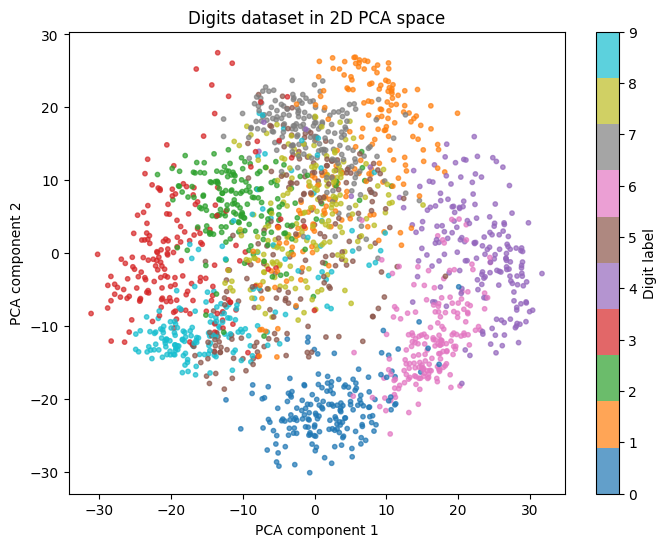

In [12]:
import matplotlib.pyplot as plt

# 1) 2D PCA
pca_2 = PCA(n_components=2, random_state=0)
X_pca_2 = pca_2.fit_transform(X)

# 2) Scatter plot, colored by true digit
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_2[:, 0], X_pca_2[:, 1],
    c=y, cmap="tab10", s=10, alpha=0.7
)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Digits dataset in 2D PCA space")
plt.show()


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

# K-means directly on raw pixels
kmeans_raw = KMeans(n_clusters=10, random_state=0, n_init=10)
clusters_raw = kmeans_raw.fit_predict(X)

cm_raw = confusion_matrix(y, clusters_raw)
print("Confusion matrix – KMeans on RAW pixels (rows=true digits, cols=clusters):")
print(cm_raw)


Confusion matrix – KMeans on RAW pixels (rows=true digits, cols=clusters):
[[176   0   0   0   0   0   2   0   0   0]
 [  0 100   0  54   1   2   0   1   0  24]
 [  1   8   3   2  13   0   0   0   2 148]
 [  0   7   7   0 154   0   0   2  13   0]
 [  0   2  11   3   0   0 165   0   0   0]
 [  0   0   0   0   2   1   2 136  41   0]
 [  1   3   0   0   0 177   0   0   0   0]
 [  0   2 174   2   0   0   0   1   0   0]
 [  0 100   5   6   2   2   0   4  52   3]
 [  0   1   8  20   6   0   0   6 139   0]]


Digit 8 is most common in cluster 1
Number of samples in that cluster: 223


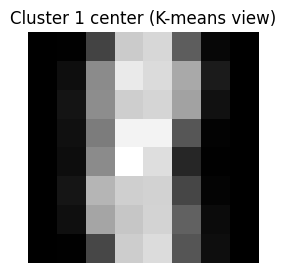

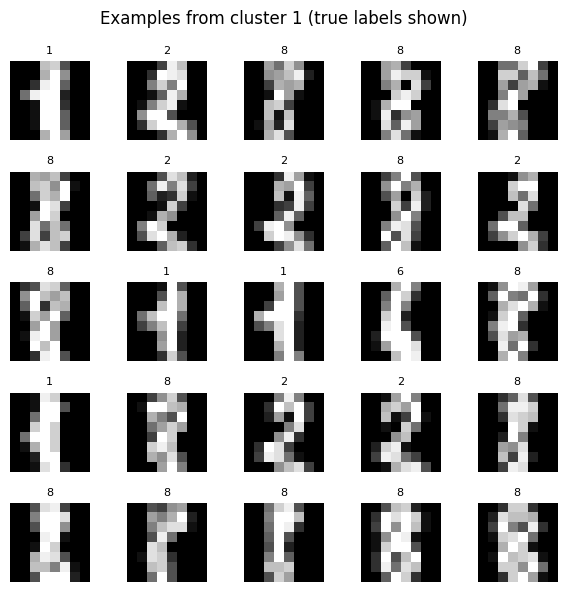

In [14]:
import numpy as np
import matplotlib.pyplot as plt

digit_of_interest = 8

# 1) Find which cluster has the most of this digit (row in cm_raw)
cluster_for_8 = cm_raw[digit_of_interest].argmax()
print(f"Digit {digit_of_interest} is most common in cluster {cluster_for_8}")

# 2) Indices of all samples assigned to that cluster
indices = np.where(clusters_raw == cluster_for_8)[0]
print("Number of samples in that cluster:", len(indices))

# 3) Show the K-means cluster center as an image
center_image = kmeans_raw.cluster_centers_[cluster_for_8].reshape(8, 8)

plt.figure(figsize=(3, 3))
plt.imshow(center_image, cmap="gray")
plt.axis("off")
plt.title(f"Cluster {cluster_for_8} center (K-means view)")
plt.show()

# 4) Show a grid of real digits from that cluster, with true labels
n_show = 25  # show 25 examples
plt.figure(figsize=(6, 6))
for i, idx in enumerate(indices[:n_show]):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X[idx].reshape(8, 8), cmap="gray")
    plt.axis("off")
    plt.title(str(y[idx]), fontsize=8)
plt.suptitle(f"Examples from cluster {cluster_for_8} (true labels shown)")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# X, y already defined as digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=5)  # k=5 is a common starting point
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("k-NN accuracy on raw pixels:", accuracy_score(y_test, y_pred_knn))


k-NN accuracy on raw pixels: 0.9777777777777777


In [16]:
from sklearn.decomposition import PCA

pca_20 = PCA(n_components=20, random_state=0)
X_pca_20 = pca_20.fit_transform(X)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca_20, y, test_size=0.2, random_state=0, stratify=y
)

knn_p = KNeighborsClassifier(n_neighbors=5)
knn_p.fit(X_train_p, y_train_p)

y_pred_knn_p = knn_p.predict(X_test_p)
print("k-NN accuracy on PCA-20 features:", accuracy_score(y_test_p, y_pred_knn_p))


k-NN accuracy on PCA-20 features: 0.9777777777777777
